# Evaluating CNN Performance on MRI Scans and Low-Salience Shape Recognition

Code behind our IEEE-format paper by **Joshua Ayaku and Gerardo Lozano** (The University of Texas at Dallas).

We look at why dementia MRI scans are hard to stage even when the overall accuracy looks great. The visual differences between Non Demented, Very Mild, Mild and Moderate Dementia are subtle, which is what we call **low-salience shape recognition**.

Three models are trained on 86,437 brain MRI slices resized to 32x32:

* **LeNet-5** as the classic CNN baseline (ReLU and max pooling instead of tanh and average pooling)
* **MLP** as the "straw man" that throws away all spatial structure
* **DementiaCNN**, our custom network with Squeeze-and-Excite attention, batch norm and a depthwise-separable refinement stage

Fashion-MNIST is used as a clean, balanced, high-salience reference so we can separate the effect of data quality from the effect of the architecture. Finally, Canny, Sobel and our own **edge irregularity** score are compared against per-image accuracy.

### Results (this notebook, also reported in the paper)

| Model | Dataset | Test accuracy | Macro F1 |
|---|---|---|---|
| LeNet-5 | Dementia MRI | 98.96% | 0.988 |
| MLP | Dementia MRI | 93.57% | 0.839 |
| DementiaCNN | Dementia MRI | **99.99%** | **0.9998** |
| LeNet-5 | Fashion-MNIST | 89.45% | 0.894 |
| MLP | Fashion-MNIST | 86.91% | 0.869 |

A fixed random seed is set below, so a rerun should reproduce these numbers closely. Keep in mind the split is by image rather than by patient, so these scores likely overstate performance on brand new patients.

### How to run

1. Put the dataset zip (`archive.zip`, with a `Data/` folder holding one subfolder per class) next to this notebook.
2. Install the requirements: `pip install torch torchvision scikit-learn opencv-python umap-learn seaborn pandas matplotlib pillow`
3. Run all cells from top to bottom. A GPU helps a lot, the full run is slow on CPU.

Figures are written to `figures/` and trained weights to `models/`.

## 1. Setup

In [1]:
import random
import zipfile
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import datasets, transforms

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import umap.umap_ as umap

In [2]:
SEED = 42

# Paths are relative so the notebook works on any machine
ZIP_PATH   = Path("archive.zip")
EXTRACT_TO = Path("extracted")
OUTPUT_CSV = Path("labeled_dataset.csv")
FIG_DIR    = Path("figures")
MODEL_DIR  = Path("models")
FIG_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)

BATCH_SIZE = 32
IMG_SIZE   = 32

# The dataset has no metadata file, the folder name is the label
LABEL_MAP = {
    "Mild Dementia":      0,
    "Moderate Dementia":  1,
    "Non Demented":       2,
    "Very mild Dementia": 3,
}
DEMENTIA_CLASSES = list(LABEL_MAP)
FASHION_CLASSES  = ["T-shirt", "Trouser", "Pullover", "Dress", "Coat",
                    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle Boot"]
IMAGE_EXTENSIONS = {".jpg"}


def set_seed(seed=SEED):
    # Called before every model is built so each one starts from the same place
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## 2. Dementia MRI data

The zip is organised into four class folders. We walk those folders, give each image the label of its folder and keep everything in a dataframe (also saved to CSV so you can inspect it).

In [3]:
def find_data_dir(root):
    # The Data folder can sit at the top of the zip or one level down
    candidates = [root / "Data", root / "data"]
    candidates += [child / name for child in sorted(root.iterdir()) if child.is_dir()
                   for name in ("Data", "data")]
    for candidate in candidates:
        if candidate.is_dir():
            return candidate
    return None


def extract_zip(zip_path, extract_to):
    # Unzipping 86k images takes a while, so only do it the first time
    data_dir = find_data_dir(extract_to) if extract_to.exists() else None
    if data_dir is None:
        with zipfile.ZipFile(zip_path, "r") as zf:
            zf.extractall(extract_to)
        data_dir = find_data_dir(extract_to)
    if data_dir is None:
        raise FileNotFoundError("Could not find a Data folder inside the zip.")
    return data_dir


def build_label_dataframe(data_dir):
    records = []
    for class_name, label in LABEL_MAP.items():
        class_folder = data_dir / class_name
        if not class_folder.exists():
            print(f"Warning: missing folder {class_folder}")
            continue
        for fp in class_folder.iterdir():
            if fp.is_file() and fp.suffix.lower() in IMAGE_EXTENSIONS:
                records.append({"file_path": str(fp), "class_name": class_name, "label": label})
    return pd.DataFrame(records, columns=["file_path", "class_name", "label"])


data_dir = extract_zip(ZIP_PATH, EXTRACT_TO)
df = build_label_dataframe(data_dir)
df.to_csv(OUTPUT_CSV, index=False)

# Class balance matters a lot here, Non Demented is roughly 77% of the data
counts = df.groupby(["label", "class_name"]).size().reset_index(name="count")
counts["share"] = (100 * counts["count"] / len(df)).round(2)
print(counts.to_string(index=False))
print(f"\nTotal: {len(df)} images")

 label         class_name  count  share
     0      Mild Dementia   5002   5.79
     1  Moderate Dementia    488   0.56
     2       Non Demented  67222  77.77
     3 Very mild Dementia  13725  15.88

Total: 86437 images


In [4]:
# Same preprocessing for every MRI: single channel, 32x32, float tensor in [0, 1]
# No augmentation was used in the paper
mri_transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])


class DementiaDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.paths = dataframe["file_path"].tolist()
        self.labels = dataframe["label"].astype(int).tolist()
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx])
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]


dataset = DementiaDataset(df, transform=mri_transform)

# 70 / 15 / 15 random split (not stratified, same as the paper)
train_size = int(0.70 * len(dataset))
val_size   = int(0.15 * len(dataset))
test_size  = len(dataset) - train_size - val_size
train_set, val_set, test_set = random_split(
    dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(SEED),
)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,
                          generator=torch.Generator().manual_seed(SEED))
val_loader   = DataLoader(val_set,  batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(train_set)} | Val: {len(val_set)} | Test: {len(test_set)}")

Train: 60505 | Val: 12965 | Test: 12967


## 3. Fashion-MNIST reference data

Fashion-MNIST is clean and perfectly balanced, which makes it a more honest benchmark than the imbalanced MRI set. Images are upscaled from 28x28 to 32x32 so the exact same LeNet-5 and MLP can be used, and normalized to [-1, 1]. The official 60k training set gets an 80 / 20 train and validation split and the official 10k test set is kept for testing.

In [5]:
fashion_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

fashion_train_full = datasets.FashionMNIST(root="./data", train=True,  download=True, transform=fashion_transform)
fashion_test_set   = datasets.FashionMNIST(root="./data", train=False, download=True, transform=fashion_transform)

fashion_train_size = int(0.8 * len(fashion_train_full))
fashion_val_size   = len(fashion_train_full) - fashion_train_size
fashion_train_set, fashion_val_set = random_split(
    fashion_train_full, [fashion_train_size, fashion_val_size],
    generator=torch.Generator().manual_seed(SEED),
)

fashion_train_loader = DataLoader(fashion_train_set, batch_size=BATCH_SIZE, shuffle=True,
                                  generator=torch.Generator().manual_seed(SEED))
fashion_val_loader   = DataLoader(fashion_val_set,  batch_size=BATCH_SIZE, shuffle=False)
fashion_test_loader  = DataLoader(fashion_test_set, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(fashion_train_set)} | Val: {len(fashion_val_set)} | Test: {len(fashion_test_set)}")

100%|██████████| 26.4M/26.4M [00:02<00:00, 9.23MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 177kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.43MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 15.6MB/s]


Train: 48000 | Val: 12000 | Test: 10000


## 4. Dataset visualization with PCA and UMAP

Every MRI is flattened to a 1024-dim vector, z-scored with `StandardScaler`, and reduced with PCA down to the components that keep 95% of the variance (about 230). UMAP then runs on the PCA output, which is much faster than running it on raw pixels.

This step is only for visualization. All three models are trained on the 32x32 images themselves.

In [6]:
# Pull every image into one big matrix. 86k images at 32x32 is only ~350 MB
feature_loader = DataLoader(dataset, batch_size=1000, shuffle=False)
all_features, all_labels = [], []
for images, labels in feature_loader:
    all_features.append(images.view(images.size(0), -1).numpy())
    all_labels.append(labels.numpy())

X = np.vstack(all_features)
y = np.concatenate(all_labels)

X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=0.95, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)

print(f"Original shape:     {X.shape}")
print(f"PCA reduced shape:  {X_pca.shape}")
print(f"Variance explained: {pca.explained_variance_ratio_.sum():.2f}")

Original shape:     (86437, 1024)
PCA reduced shape:  (86437, 230)
Variance explained: 0.95


C:\Users\gerar\AppData\Roaming\Python\Python313\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\gerar\AppData\Roaming\Python\Python313\site-packages\sklearn\manifold\_spectral_embedding.py:325: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


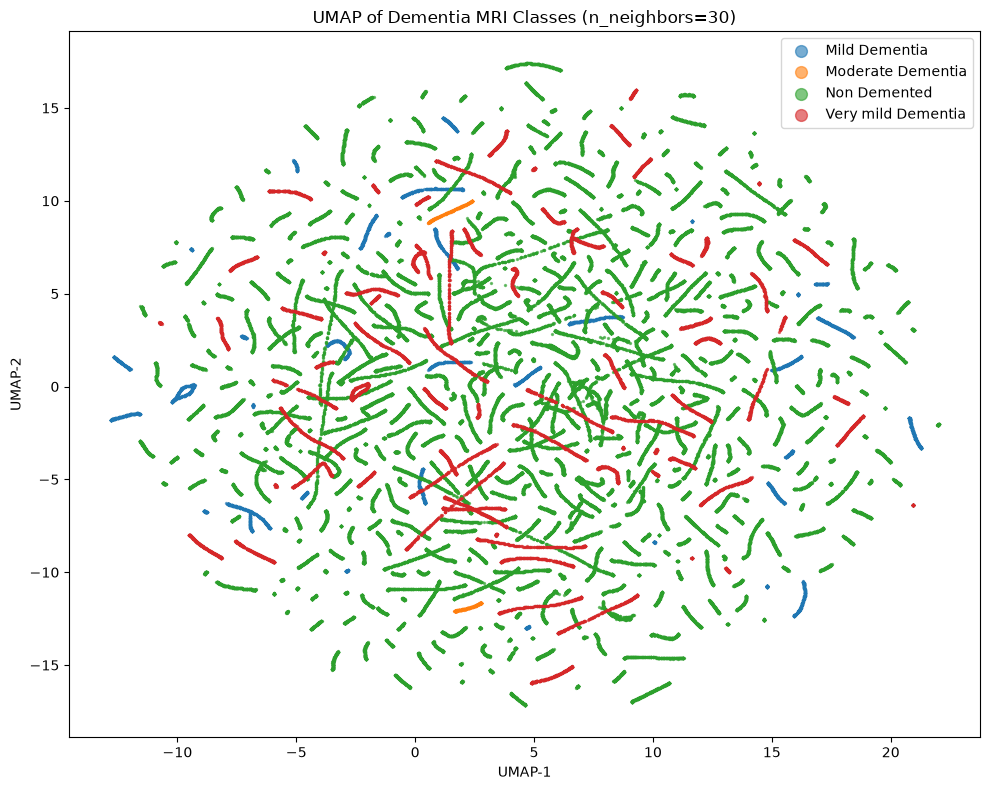

C:\Users\gerar\AppData\Roaming\Python\Python313\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


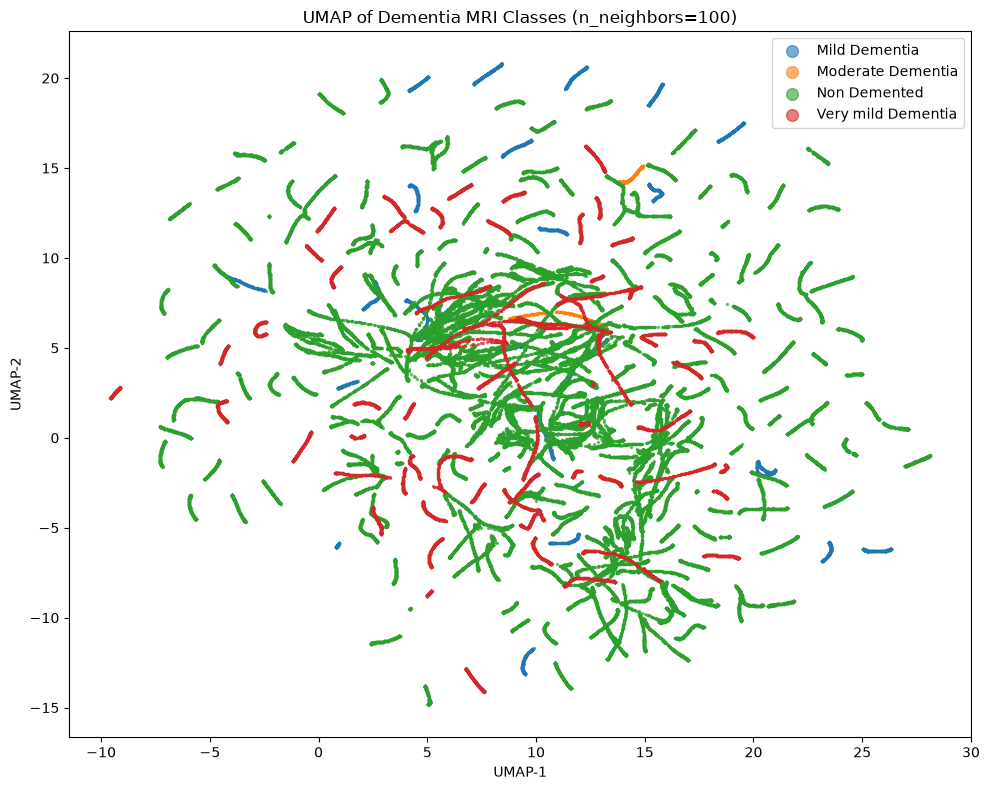

C:\Users\gerar\AppData\Roaming\Python\Python313\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


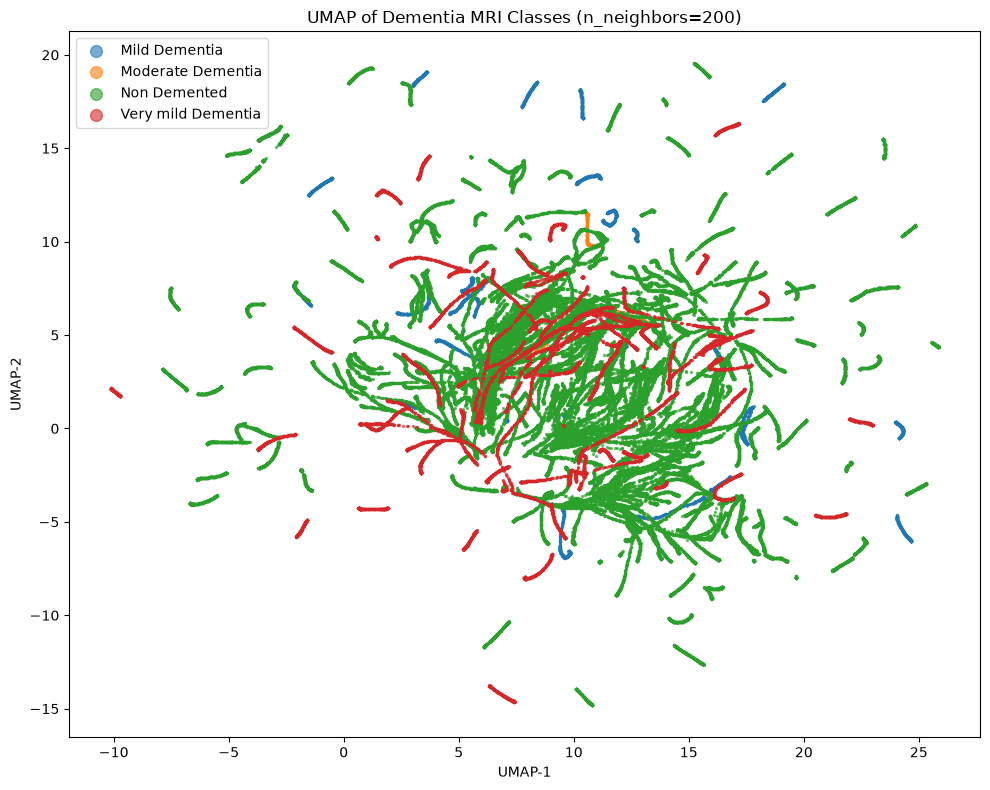

In [7]:
def plot_umap(embedding, labels, n_neighbors):
    plt.figure(figsize=(10, 8))
    for label, name in enumerate(DEMENTIA_CLASSES):
        mask = labels == label
        plt.scatter(embedding[mask, 0], embedding[mask, 1], s=2, alpha=0.6, label=name)
    plt.title(f"UMAP of Dementia MRI Classes (n_neighbors={n_neighbors})")
    plt.xlabel("UMAP-1")
    plt.ylabel("UMAP-2")
    plt.legend(markerscale=6)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"umap_n{n_neighbors}.png", dpi=150)
    plt.show()


# We tried a few neighborhood sizes. Moderate Dementia blends into the
# other classes more and more as n_neighbors grows
# Heads up, n_neighbors=200 on 86k points takes a while
for n_neighbors in [30, 100, 200]:
    reducer = umap.UMAP(n_components=2, n_neighbors=n_neighbors, min_dist=0.1,
                        metric="euclidean", random_state=SEED)
    X_umap = reducer.fit_transform(X_pca)
    plot_umap(X_umap, y, n_neighbors)

## 5. Model architectures

In [8]:
class LeNet5(nn.Module):
    """LeNet-5 with ReLU and max pooling in place of the original tanh and average pooling."""

    def __init__(self, num_classes=4):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        # 32 -> conv 28 -> pool 14 -> conv 10 -> pool 5, so 16 maps of 5x5
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, num_classes)

    def forward(self, x):
        x = F.max_pool2d(F.relu(self.conv1(x)), kernel_size=2, stride=2)
        x = F.max_pool2d(F.relu(self.conv2(x)), kernel_size=2, stride=2)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)


class MLP(nn.Module):
    """Fully connected baseline. Flattening the image throws away every spatial relationship."""

    def __init__(self, num_classes):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(IMG_SIZE * IMG_SIZE, 512),
            nn.ReLU(),
            nn.Dropout(0.3),  # dropout after the first two layers keeps the big 1024x512 layer from overfitting
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.model(x)

In [9]:
class SEBlock(nn.Module):
    """Squeeze-and-Excite channel attention.

    Global average pooling summarises each feature map, a tiny MLP scores it,
    and the maps get rescaled by those scores. This lets the network turn down
    channels that are mostly picking up scanner noise.
    """

    def __init__(self, channels, reduction=8):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, x):
        b, c, _, _ = x.shape
        weights = self.fc(self.pool(x).view(b, c)).view(b, c, 1, 1)
        return x * weights


class DSConv(nn.Module):
    """Depthwise 3x3 followed by pointwise 1x1. Same receptive field as a full conv with far fewer weights."""

    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.dw = nn.Conv2d(in_ch, in_ch, 3, padding=1, groups=in_ch, bias=False)
        self.pw = nn.Conv2d(in_ch, out_ch, 1, bias=False)
        self.bn = nn.BatchNorm2d(out_ch)

    def forward(self, x):
        return F.relu(self.bn(self.pw(self.dw(x))), inplace=True)


class DementiaCNN(nn.Module):
    """Custom CNN for 4-class dementia staging from 32x32 grayscale MRI.

    Input (B, 1, 32, 32), output (B, 4) raw logits.
    """

    def __init__(self, num_classes=4, dropout=0.4):
        super().__init__()

        # Block 1: two convs before pooling so subtle texture survives two
        # nonlinear passes before we throw resolution away. 32x32 -> 16x16
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.se1 = SEBlock(32)

        # Block 2: 16x16 -> 8x8
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.se2 = SEBlock(64)

        # Block 3: 8x8 -> 4x4
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.se3 = SEBlock(128)

        # Fine detail refinement at 4x4 without shrinking any further
        self.ds = DSConv(128, 128)

        # Global average pooling instead of flattening keeps the head small,
        # which is where small CNNs usually overfit
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(128, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout / 2),
            nn.Linear(256, num_classes),
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.se1(self.block1(x))
        x = self.se2(self.block2(x))
        x = self.se3(self.block3(x))
        x = self.ds(x)
        x = self.gap(x)
        return self.head(x)


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

## 6. Training and evaluation helpers

Every model goes through the same loop. The optional pieces (scheduler, gradient clipping, early stopping) are only switched on for DementiaCNN, matching the setup described in the paper.

In [10]:
def run_epoch(model, loader, criterion, optimizer=None, clip_norm=None):
    """One pass over the loader. Trains if an optimizer is given, otherwise just evaluates."""
    training = optimizer is not None
    model.train(training)
    total_loss, correct, total = 0.0, 0, 0

    with torch.set_grad_enabled(training):
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            if training:
                optimizer.zero_grad()
                loss.backward()
                if clip_norm is not None:
                    nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_norm)
                optimizer.step()

            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)

    return total_loss / len(loader), 100.0 * correct / total


def train_model(model, train_loader, val_loader, criterion, optimizer, epochs,
                scheduler=None, clip_norm=None, patience=None, checkpoint_path=None):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_loss = float("inf")
    epochs_without_improvement = 0

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer, clip_norm)
        val_loss, val_acc = run_epoch(model, val_loader, criterion)
        if scheduler is not None:
            scheduler.step()

        for key, value in zip(history, (train_loss, train_acc, val_loss, val_acc)):
            history[key].append(value)
        print(f"Epoch {epoch:02d}/{epochs} | Train Loss: {train_loss:.4f}  Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.2f}%")

        if patience is None:
            continue

        # Early stopping on validation loss, keeping the best weights on disk
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_without_improvement = 0
            torch.save(model.state_dict(), checkpoint_path)
            print(f"  saved new best model (val loss {val_loss:.4f})")
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f"  early stopping at epoch {epoch}")
                break

    if patience is not None:
        model.load_state_dict(torch.load(checkpoint_path, map_location=device, weights_only=True))
        print("Best weights reloaded.")
    return history


@torch.no_grad()
def predict(model, loader):
    model.eval()
    all_labels, all_preds, all_probs = [], [], []
    for images, labels in loader:
        probs = F.softmax(model(images.to(device)), dim=1).cpu()
        all_labels.append(labels)
        all_preds.append(probs.argmax(1))
        all_probs.append(probs)
    return torch.cat(all_labels).numpy(), torch.cat(all_preds).numpy(), torch.cat(all_probs).numpy()

In [11]:
def slug(text):
    return text.lower().replace(" ", "_").replace("-", "")


def plot_history(history, title):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(epochs, history["train_loss"], marker="o", color="steelblue", label="Train")
    axes[0].plot(epochs, history["val_loss"], marker="o", color="tomato", label="Val")
    axes[0].set_title(f"{title}: Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")

    axes[1].plot(epochs, history["train_acc"], marker="o", color="steelblue", label="Train")
    axes[1].plot(epochs, history["val_acc"], marker="o", color="tomato", label="Val")
    axes[1].set_title(f"{title}: Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy (%)")

    for ax in axes:
        ax.legend()
        ax.grid(True)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{slug(title)}_curves.png", dpi=150, bbox_inches="tight")
    plt.show()


def evaluate(title, labels, preds, class_names, cmap="Blues"):
    """Prints test accuracy and the classification report, and plots the confusion matrix."""
    accuracy = 100.0 * (preds == labels).mean()
    print(f"{title} test accuracy: {accuracy:.2f}%\n")

    cm = confusion_matrix(labels, preds)
    size = (8, 6) if len(class_names) <= 4 else (10, 8)
    plt.figure(figsize=size)
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap, xticklabels=class_names, yticklabels=class_names)
    plt.title(f"{title}: Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{slug(title)}_confusion_matrix.png", dpi=150)
    plt.show()

    # Macro F1 is the number to watch on the MRI data since it weights every class equally
    print(classification_report(labels, preds, target_names=class_names, digits=4))
    return {
        "Model": title,
        "Test accuracy (%)": round(accuracy, 2),
        "Macro F1": round(f1_score(labels, preds, average="macro"), 4),
        "Weighted F1": round(f1_score(labels, preds, average="weighted"), 4),
    }


results = []      # summary rows for the final table
predictions = {}  # test set predictions, reused by the edge analysis

## 7. Dementia MRI experiments

### 7.1 LeNet-5
Adam, learning rate 0.001, batch size 32, 10 epochs, plain cross-entropy.

LeNet5(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=4, bias=True)
)
Trainable parameters: 61,196

Epoch 01/10 | Train Loss: 0.5382  Acc: 79.52% | Val Loss: 0.4623  Acc: 82.75%
Epoch 02/10 | Train Loss: 0.3271  Acc: 87.15% | Val Loss: 0.2560  Acc: 90.01%
Epoch 03/10 | Train Loss: 0.1628  Acc: 93.90% | Val Loss: 0.2137  Acc: 91.50%
Epoch 04/10 | Train Loss: 0.0822  Acc: 97.06% | Val Loss: 0.0516  Acc: 98.29%
Epoch 05/10 | Train Loss: 0.0537  Acc: 98.08% | Val Loss: 0.0541  Acc: 98.06%
Epoch 06/10 | Train Loss: 0.0369  Acc: 98.72% | Val Loss: 0.0307  Acc: 98.97%
Epoch 07/10 | Train Loss: 0.0317  Acc: 98.87% | Val Loss: 0.0239  Acc: 99.19%
Epoch 08/10 | Train Loss: 0.0279  Acc: 99.05% | Val Loss: 0.0387  Acc: 98.74%
Epoch 09/10 | Train Loss: 0.0241  A

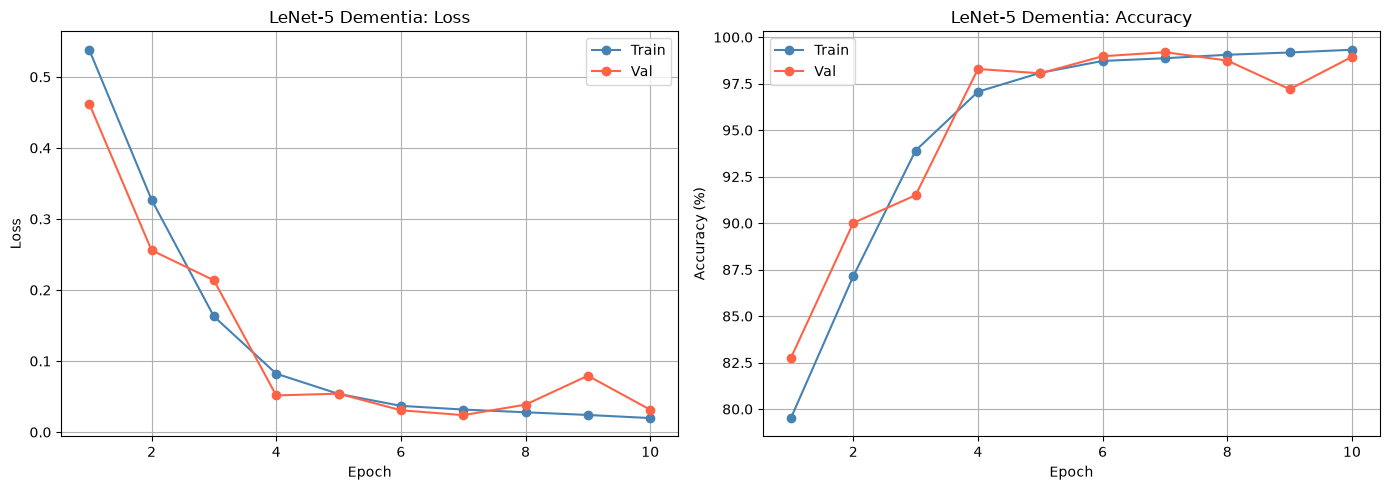

In [12]:
set_seed()
lenet_dementia = LeNet5(num_classes=4).to(device)
print(lenet_dementia)
print(f"Trainable parameters: {count_params(lenet_dementia):,}\n")

lenet_dementia_history = train_model(
    lenet_dementia, train_loader, val_loader,
    criterion=nn.CrossEntropyLoss(),
    optimizer=optim.Adam(lenet_dementia.parameters(), lr=0.001),
    epochs=10,
)
plot_history(lenet_dementia_history, "LeNet-5 Dementia")

LeNet-5 Dementia test accuracy: 98.96%



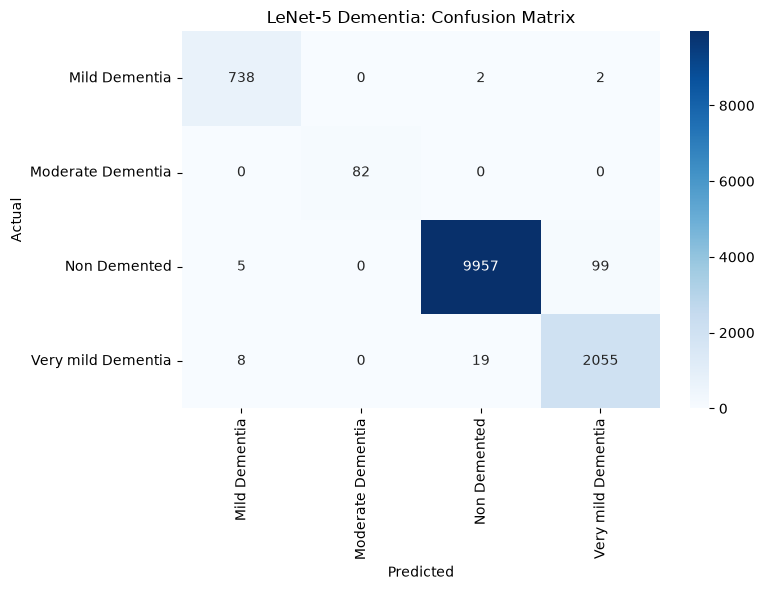

                    precision    recall  f1-score   support

     Mild Dementia     0.9827    0.9946    0.9886       742
 Moderate Dementia     1.0000    1.0000    1.0000        82
      Non Demented     0.9979    0.9897    0.9938     10061
Very mild Dementia     0.9532    0.9870    0.9698      2082

          accuracy                         0.9896     12967
         macro avg     0.9834    0.9928    0.9880     12967
      weighted avg     0.9899    0.9896    0.9897     12967



In [13]:
labels, preds, _ = predict(lenet_dementia, test_loader)
predictions["LeNet-5 Dementia"] = (labels, preds)
results.append(evaluate("LeNet-5 Dementia", labels, preds, DEMENTIA_CLASSES))

### 7.2 MLP
Same optimizer, learning rate, batch size and epoch count as LeNet-5. The MLP is fed the same 32x32 images, flattened to 1024 values.

MLP(
  (model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1024, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.3, inplace=False)
    (7): Linear(in_features=256, out_features=128, bias=True)
    (8): ReLU()
    (9): Linear(in_features=128, out_features=4, bias=True)
  )
)
Trainable parameters: 689,540

Epoch 01/10 | Train Loss: 0.5420  Acc: 79.31% | Val Loss: 0.4638  Acc: 80.86%
Epoch 02/10 | Train Loss: 0.4331  Acc: 82.32% | Val Loss: 0.3552  Acc: 85.58%
Epoch 03/10 | Train Loss: 0.3748  Acc: 84.57% | Val Loss: 0.3138  Acc: 86.78%
Epoch 04/10 | Train Loss: 0.3373  Acc: 86.09% | Val Loss: 0.3001  Acc: 87.02%
Epoch 05/10 | Train Loss: 0.3051  Acc: 86.91% | Val Loss: 0.2252  Acc: 91.32%
Epoch 06/10 | Train Loss: 0.2875  Acc: 87.70% | Val Loss: 0.2211  Acc: 91.49%
Epoch 07/10 | Train Loss: 0.2597  Acc: 89.22% | Val 

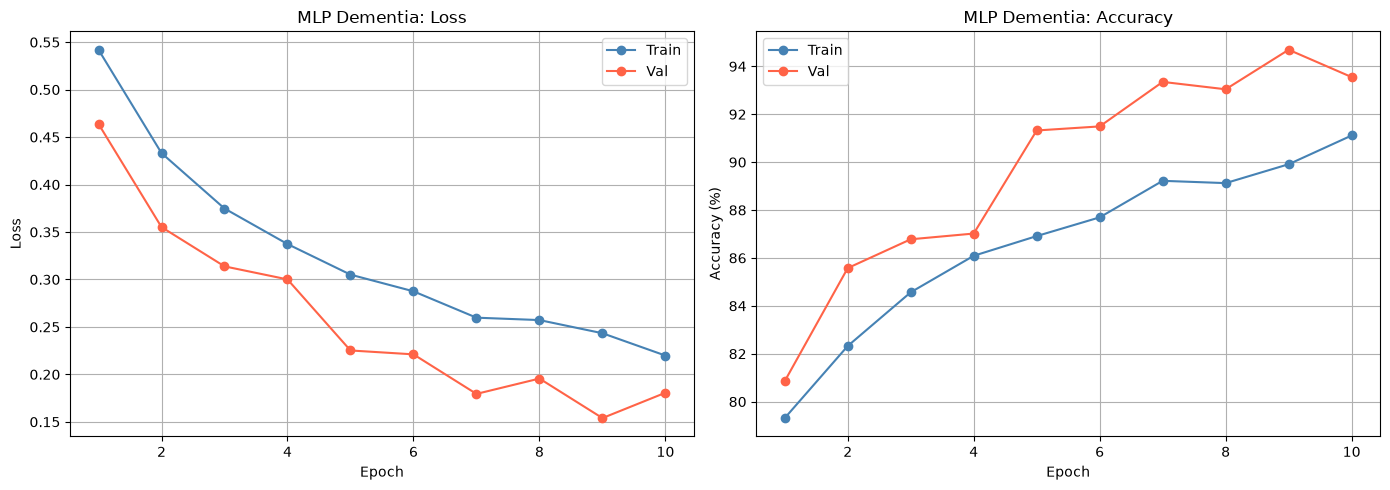

In [14]:
set_seed()
mlp_dementia = MLP(num_classes=4).to(device)
print(mlp_dementia)
print(f"Trainable parameters: {count_params(mlp_dementia):,}\n")

mlp_dementia_history = train_model(
    mlp_dementia, train_loader, val_loader,
    criterion=nn.CrossEntropyLoss(),
    optimizer=optim.Adam(mlp_dementia.parameters(), lr=0.001),
    epochs=10,
)
plot_history(mlp_dementia_history, "MLP Dementia")

MLP Dementia test accuracy: 93.57%



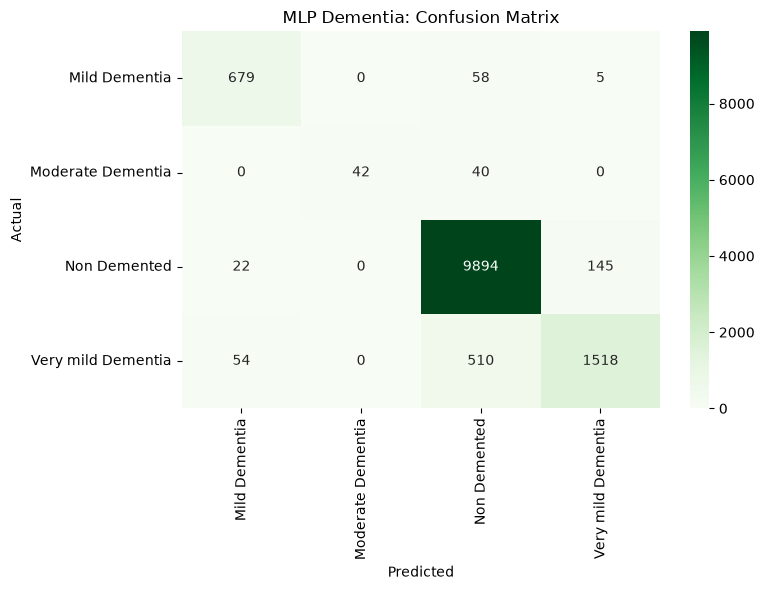

                    precision    recall  f1-score   support

     Mild Dementia     0.8993    0.9151    0.9071       742
 Moderate Dementia     1.0000    0.5122    0.6774        82
      Non Demented     0.9421    0.9834    0.9623     10061
Very mild Dementia     0.9101    0.7291    0.8096      2082

          accuracy                         0.9357     12967
         macro avg     0.9379    0.7849    0.8391     12967
      weighted avg     0.9349    0.9357    0.9328     12967



In [15]:
labels, preds, _ = predict(mlp_dementia, test_loader)
predictions["MLP Dementia"] = (labels, preds)
results.append(evaluate("MLP Dementia", labels, preds, DEMENTIA_CLASSES, cmap="Greens"))

### 7.3 DementiaCNN
AdamW (lr 3e-4, weight decay 1e-4) with cosine annealing over up to 25 epochs, label smoothing of 0.05, gradient clipping at 1.0 and early stopping with a patience of 6 on validation loss.

DementiaCNN(
  (block1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (se1): SEBlock(
    (pool): AdaptiveAvgPool2d(output_size=1)
    (fc): Sequential(
      (0): Linear(in_features=32, out_features=4, bias=False)
      (1): ReLU(inplace=True)
      (2): Linear(in_features=4, out_features=32, bias=False)
      (3): Sigmoid()
    )
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bi

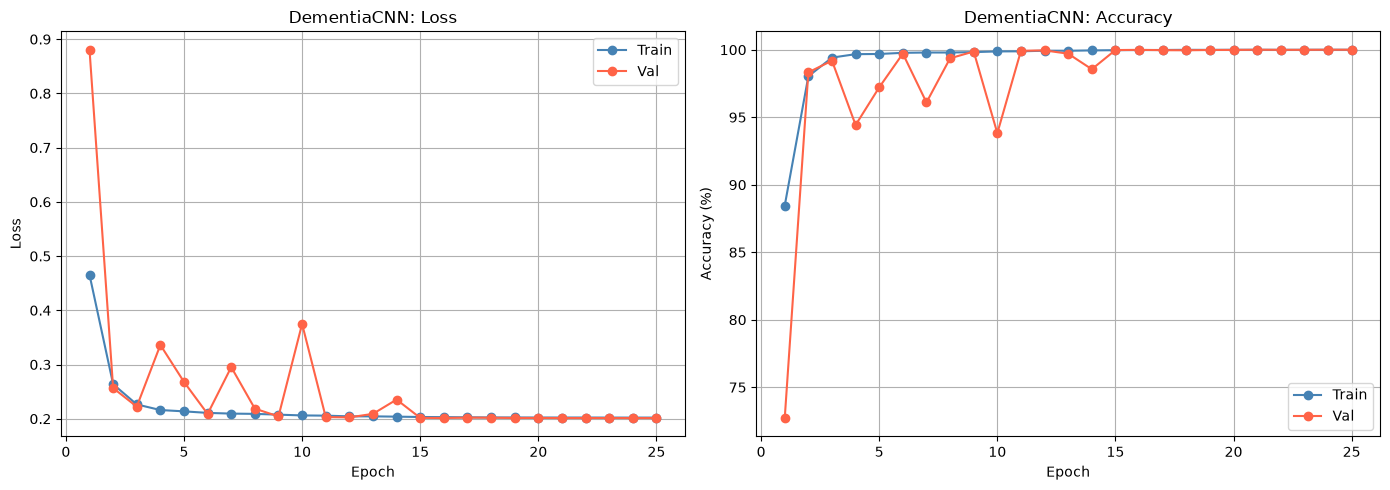

In [16]:
set_seed()
dementia_cnn = DementiaCNN(num_classes=4, dropout=0.4).to(device)
print(dementia_cnn)
print(f"Trainable parameters: {count_params(dementia_cnn):,}\n")

CNN_EPOCHS = 25
cnn_optimizer = optim.AdamW(dementia_cnn.parameters(), lr=3e-4, weight_decay=1e-4)

dementia_cnn_history = train_model(
    dementia_cnn, train_loader, val_loader,
    # Label smoothing stops the model from getting overconfident on
    # Non Demented vs Very Mild, which even clinicians find hard to call
    criterion=nn.CrossEntropyLoss(label_smoothing=0.05),
    optimizer=cnn_optimizer,
    epochs=CNN_EPOCHS,
    scheduler=CosineAnnealingLR(cnn_optimizer, T_max=CNN_EPOCHS, eta_min=1e-6),
    clip_norm=1.0,
    patience=6,
    checkpoint_path=MODEL_DIR / "dementia_cnn_best.pth",
)
plot_history(dementia_cnn_history, "DementiaCNN")

DementiaCNN test accuracy: 99.99%



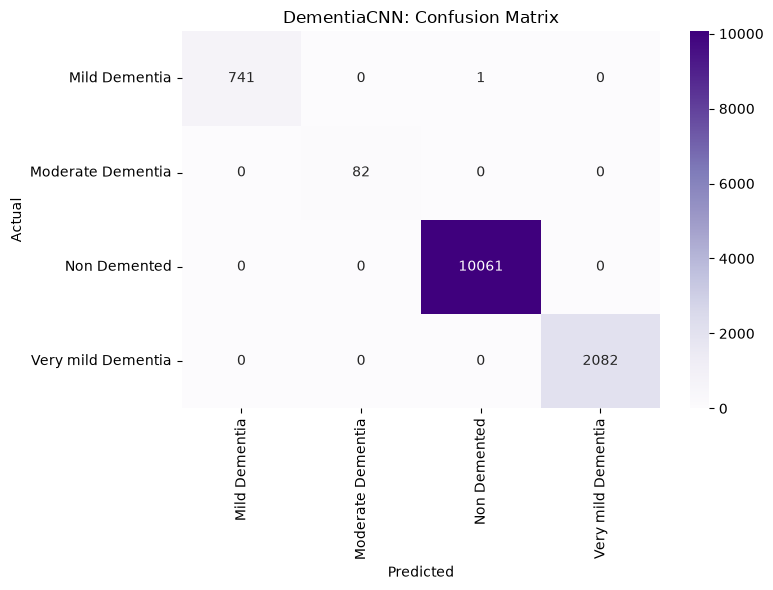

                    precision    recall  f1-score   support

     Mild Dementia     1.0000    0.9987    0.9993       742
 Moderate Dementia     1.0000    1.0000    1.0000        82
      Non Demented     0.9999    1.0000    1.0000     10061
Very mild Dementia     1.0000    1.0000    1.0000      2082

          accuracy                         0.9999     12967
         macro avg     1.0000    0.9997    0.9998     12967
      weighted avg     0.9999    0.9999    0.9999     12967



In [17]:
labels, preds, probs = predict(dementia_cnn, test_loader)
predictions["DementiaCNN"] = (labels, preds)
results.append(evaluate("DementiaCNN", labels, preds, DEMENTIA_CLASSES, cmap="Purples"))

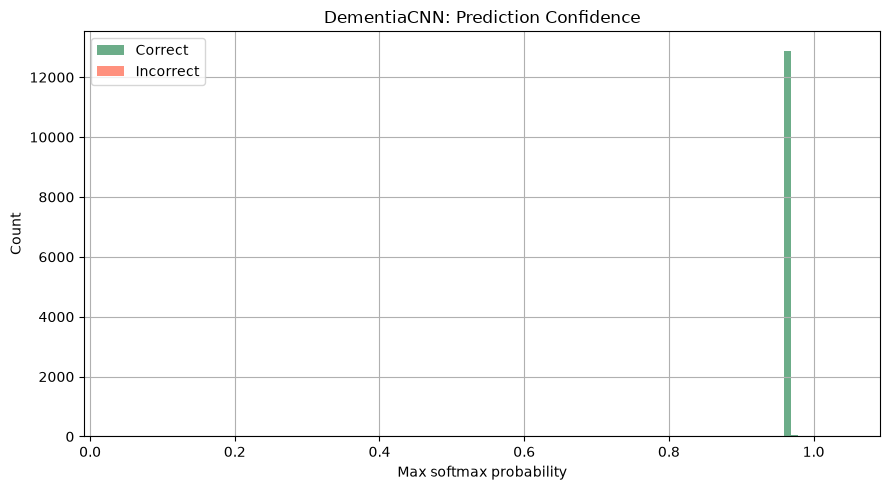

Mean confidence (correct):   0.963
Mean confidence (incorrect): 0.542


In [18]:
# A model you can trust should be less sure of itself when it is wrong
max_probs  = probs.max(axis=1)
is_correct = preds == labels

plt.figure(figsize=(9, 5))
plt.hist(max_probs[is_correct],  bins=25, alpha=0.7, color="seagreen", label="Correct")
plt.hist(max_probs[~is_correct], bins=25, alpha=0.7, color="tomato",   label="Incorrect")
plt.title("DementiaCNN: Prediction Confidence")
plt.xlabel("Max softmax probability")
plt.ylabel("Count")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(FIG_DIR / "dementiacnn_confidence.png", dpi=150)
plt.show()

print(f"Mean confidence (correct):   {max_probs[is_correct].mean():.3f}")
if (~is_correct).any():
    print(f"Mean confidence (incorrect): {max_probs[~is_correct].mean():.3f}")

## 8. Fashion-MNIST experiments

LeNet-5 and the MLP are retrained from scratch on Fashion-MNIST with the same hyperparameters. DementiaCNN is only evaluated on the MRI data.

Epoch 01/10 | Train Loss: 0.5816  Acc: 77.97% | Val Loss: 0.4295  Acc: 84.23%
Epoch 02/10 | Train Loss: 0.3800  Acc: 85.77% | Val Loss: 0.3613  Acc: 86.75%
Epoch 03/10 | Train Loss: 0.3260  Acc: 87.85% | Val Loss: 0.3257  Acc: 87.69%
Epoch 04/10 | Train Loss: 0.2954  Acc: 89.11% | Val Loss: 0.3122  Acc: 88.84%
Epoch 05/10 | Train Loss: 0.2751  Acc: 89.62% | Val Loss: 0.3117  Acc: 88.53%
Epoch 06/10 | Train Loss: 0.2551  Acc: 90.47% | Val Loss: 0.2954  Acc: 88.94%
Epoch 07/10 | Train Loss: 0.2389  Acc: 90.86% | Val Loss: 0.2961  Acc: 88.98%
Epoch 08/10 | Train Loss: 0.2240  Acc: 91.59% | Val Loss: 0.2742  Acc: 90.08%
Epoch 09/10 | Train Loss: 0.2121  Acc: 92.04% | Val Loss: 0.2798  Acc: 89.82%
Epoch 10/10 | Train Loss: 0.1988  Acc: 92.61% | Val Loss: 0.2863  Acc: 89.62%


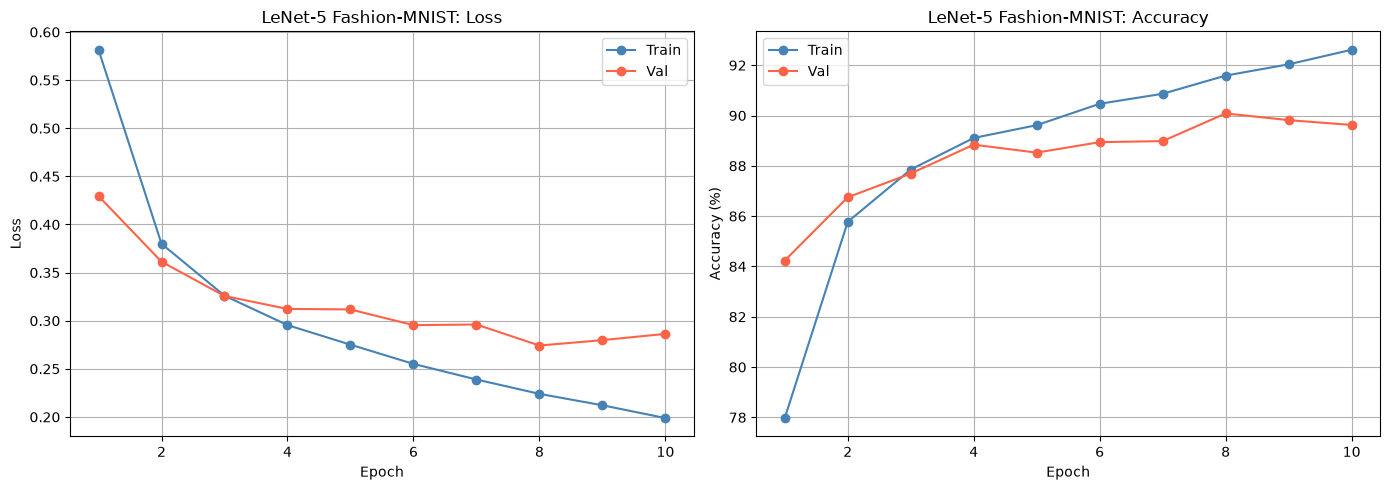

LeNet-5 Fashion-MNIST test accuracy: 89.45%



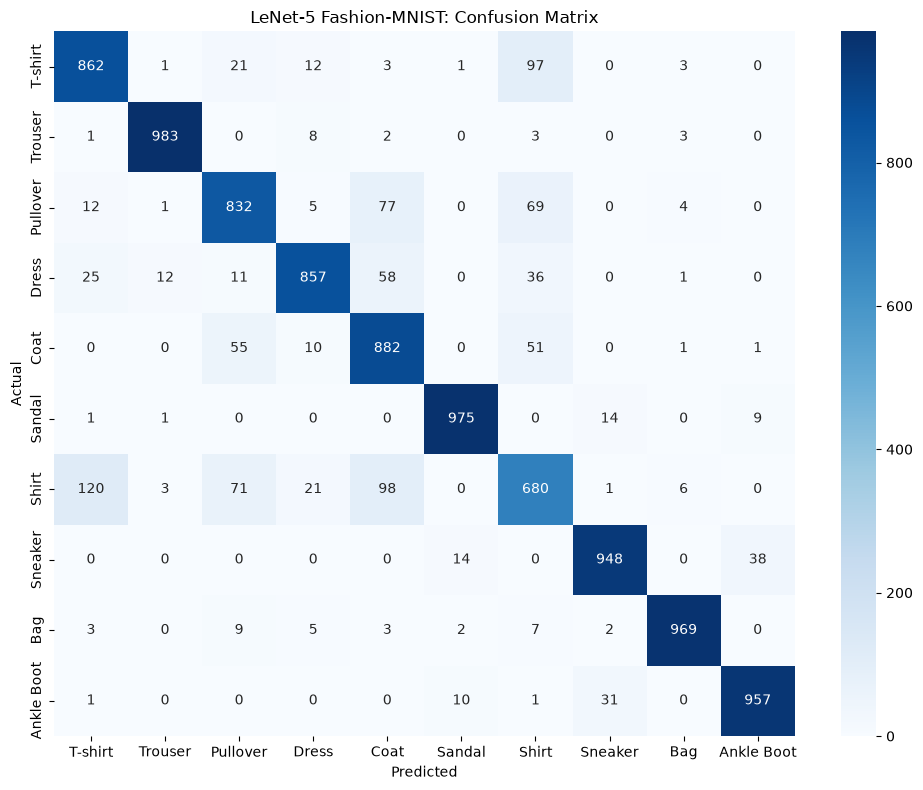

              precision    recall  f1-score   support

     T-shirt     0.8410    0.8620    0.8514      1000
     Trouser     0.9820    0.9830    0.9825      1000
    Pullover     0.8328    0.8320    0.8324      1000
       Dress     0.9336    0.8570    0.8936      1000
        Coat     0.7854    0.8820    0.8309      1000
      Sandal     0.9731    0.9750    0.9740      1000
       Shirt     0.7203    0.6800    0.6996      1000
     Sneaker     0.9518    0.9480    0.9499      1000
         Bag     0.9818    0.9690    0.9753      1000
  Ankle Boot     0.9522    0.9570    0.9546      1000

    accuracy                         0.8945     10000
   macro avg     0.8954    0.8945    0.8944     10000
weighted avg     0.8954    0.8945    0.8944     10000



In [19]:
set_seed()
lenet_fashion = LeNet5(num_classes=10).to(device)

lenet_fashion_history = train_model(
    lenet_fashion, fashion_train_loader, fashion_val_loader,
    criterion=nn.CrossEntropyLoss(),
    optimizer=optim.Adam(lenet_fashion.parameters(), lr=0.001),
    epochs=10,
)
plot_history(lenet_fashion_history, "LeNet-5 Fashion-MNIST")

labels, preds, _ = predict(lenet_fashion, fashion_test_loader)
predictions["LeNet-5 Fashion-MNIST"] = (labels, preds)
results.append(evaluate("LeNet-5 Fashion-MNIST", labels, preds, FASHION_CLASSES))

Epoch 01/10 | Train Loss: 0.5964  Acc: 77.90% | Val Loss: 0.4589  Acc: 83.36%
Epoch 02/10 | Train Loss: 0.4686  Acc: 82.87% | Val Loss: 0.4279  Acc: 84.85%
Epoch 03/10 | Train Loss: 0.4341  Acc: 84.20% | Val Loss: 0.3977  Acc: 85.74%
Epoch 04/10 | Train Loss: 0.4065  Acc: 85.20% | Val Loss: 0.3976  Acc: 86.16%
Epoch 05/10 | Train Loss: 0.3898  Acc: 85.85% | Val Loss: 0.3622  Acc: 87.53%
Epoch 06/10 | Train Loss: 0.3842  Acc: 86.04% | Val Loss: 0.3536  Acc: 87.42%
Epoch 07/10 | Train Loss: 0.3704  Acc: 86.58% | Val Loss: 0.3538  Acc: 87.38%
Epoch 08/10 | Train Loss: 0.3618  Acc: 86.81% | Val Loss: 0.3330  Acc: 88.05%
Epoch 09/10 | Train Loss: 0.3528  Acc: 87.26% | Val Loss: 0.3303  Acc: 88.21%
Epoch 10/10 | Train Loss: 0.3476  Acc: 87.32% | Val Loss: 0.3423  Acc: 88.10%


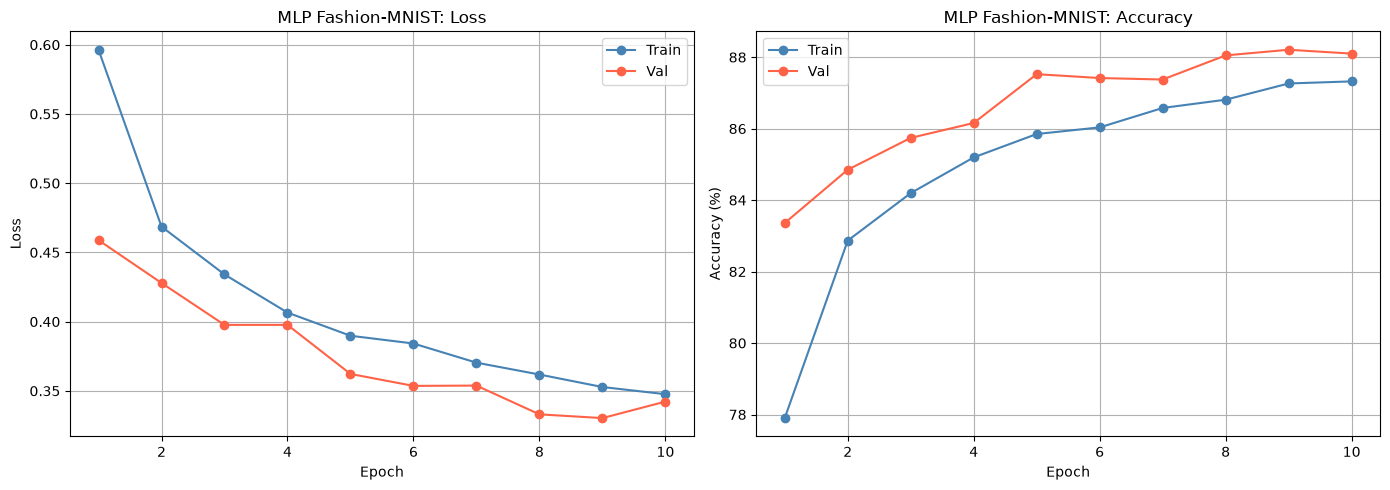

MLP Fashion-MNIST test accuracy: 86.91%



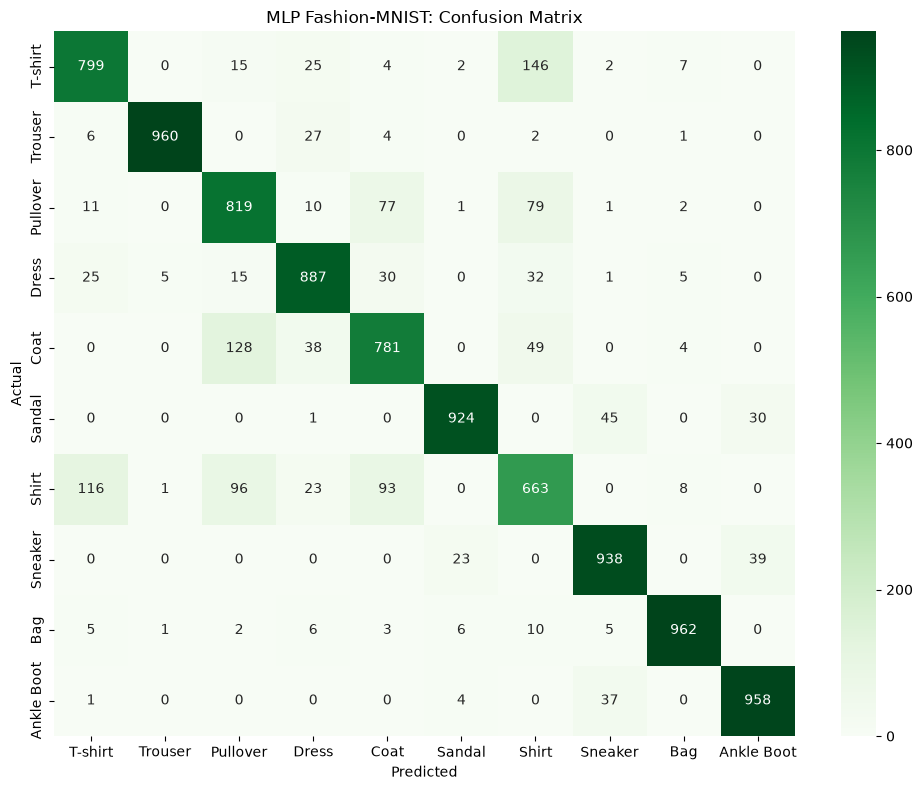

              precision    recall  f1-score   support

     T-shirt     0.8297    0.7990    0.8141      1000
     Trouser     0.9928    0.9600    0.9761      1000
    Pullover     0.7619    0.8190    0.7894      1000
       Dress     0.8722    0.8870    0.8795      1000
        Coat     0.7873    0.7810    0.7841      1000
      Sandal     0.9625    0.9240    0.9429      1000
       Shirt     0.6758    0.6630    0.6694      1000
     Sneaker     0.9116    0.9380    0.9246      1000
         Bag     0.9727    0.9620    0.9673      1000
  Ankle Boot     0.9328    0.9580    0.9452      1000

    accuracy                         0.8691     10000
   macro avg     0.8699    0.8691    0.8693     10000
weighted avg     0.8699    0.8691    0.8693     10000



In [20]:
set_seed()
mlp_fashion = MLP(num_classes=10).to(device)

mlp_fashion_history = train_model(
    mlp_fashion, fashion_train_loader, fashion_val_loader,
    criterion=nn.CrossEntropyLoss(),
    optimizer=optim.Adam(mlp_fashion.parameters(), lr=0.001),
    epochs=10,
)
plot_history(mlp_fashion_history, "MLP Fashion-MNIST")

labels, preds, _ = predict(mlp_fashion, fashion_test_loader)
predictions["MLP Fashion-MNIST"] = (labels, preds)
results.append(evaluate("MLP Fashion-MNIST", labels, preds, FASHION_CLASSES, cmap="Greens"))

## 9. Edge sensitivity analysis

Three per-image scores are computed on every test image:

* **Canny**: mean of the binary Canny edge map (thresholds 30 and 100), basically edge density
* **Sobel**: mean gradient magnitude, a continuous measure of edge strength
* **Edge irregularity** (ours): fraction of strong-edge pixels multiplied by the spread of their gradient directions. Strong edges pointing every which way look like wrinkles or folds, which a plain edge score cannot tell apart from one clean outline.

The scores are binned and the accuracy inside each bin is plotted. On Fashion-MNIST there is a clear sweet spot. On the MRI data the curve is flat and correct and incorrect predictions have almost identical average scores, which is the evidence for the low-salience argument.

In [21]:
def to_uint8(img_tensor, normalized):
    img = img_tensor.squeeze().cpu().numpy()
    # Fashion-MNIST was normalized to [-1, 1] so it needs mapping back to [0, 1].
    # The MRI tensors come straight out of ToTensor and are already in [0, 1]
    if normalized:
        img = img * 0.5 + 0.5
    return np.clip(img * 255, 0, 255).astype(np.uint8)


def sobel_gradients(img):
    gx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    return np.sqrt(gx ** 2 + gy ** 2), np.arctan2(gy, gx)


def canny_score(img):
    return cv2.Canny(img, threshold1=30, threshold2=100).mean()


def sobel_score(img):
    magnitude, _ = sobel_gradients(img)
    return magnitude.mean()


def edge_irregularity_score(img):
    magnitude, direction = sobel_gradients(img)
    # Only count pixels that are clearly edges, one std above the mean gradient
    edge_mask = magnitude > magnitude.mean() + magnitude.std()
    edge_density = edge_mask.mean()
    # How chaotic the edge orientations are
    direction_spread = direction[edge_mask].std() if edge_mask.any() else 0.0
    return edge_density * direction_spread


EDGE_METRICS = {
    "Canny":        (canny_score,             "steelblue",  "Edge Sharpness Score (Canny)"),
    "Sobel":        (sobel_score,             "darkorange", "Edge Sharpness Score (Sobel)"),
    "Irregularity": (edge_irregularity_score, "crimson",    "Edge Irregularity Score"),
}


def compute_edge_scores(loader, normalized):
    # The scores only depend on the image, so we compute them once per test set
    # and reuse them for every model. The test loaders are not shuffled, so the
    # order lines up with the predictions
    scores = {name: [] for name in EDGE_METRICS}
    for images, _ in loader:
        for img in images:
            img = to_uint8(img, normalized)
            for name, (fn, _, _) in EDGE_METRICS.items():
                scores[name].append(fn(img))
    return {name: np.array(values) for name, values in scores.items()}


def plot_edge_vs_accuracy(scores, correct, title, n_bins=20):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, (name, (_, color, xlabel)) in zip(axes, EDGE_METRICS.items()):
        values = scores[name]
        bins = np.linspace(values.min(), values.max(), n_bins)
        bin_idx = np.digitize(values, bins)
        centers, accuracy = [], []
        for b in range(1, len(bins)):
            mask = bin_idx == b
            if mask.any():
                centers.append((bins[b - 1] + bins[b]) / 2)
                accuracy.append(correct[mask].mean() * 100)
        ax.plot(centers, accuracy, marker="o", color=color, linewidth=2)
        ax.set_title(f"{name} vs Accuracy: {title}")
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Accuracy (%)")
        ax.grid(True)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"edge_{slug(title)}.png", dpi=150)
    plt.show()

    for name in EDGE_METRICS:
        values = scores[name]
        wrong = values[~correct]
        wrong_avg = f"{wrong.mean():.4f}" if wrong.size else "n/a (no errors)"
        print(f"{name:<13} avg correct: {values[correct].mean():.4f} | avg incorrect: {wrong_avg}")


LeNet-5 Fashion-MNIST


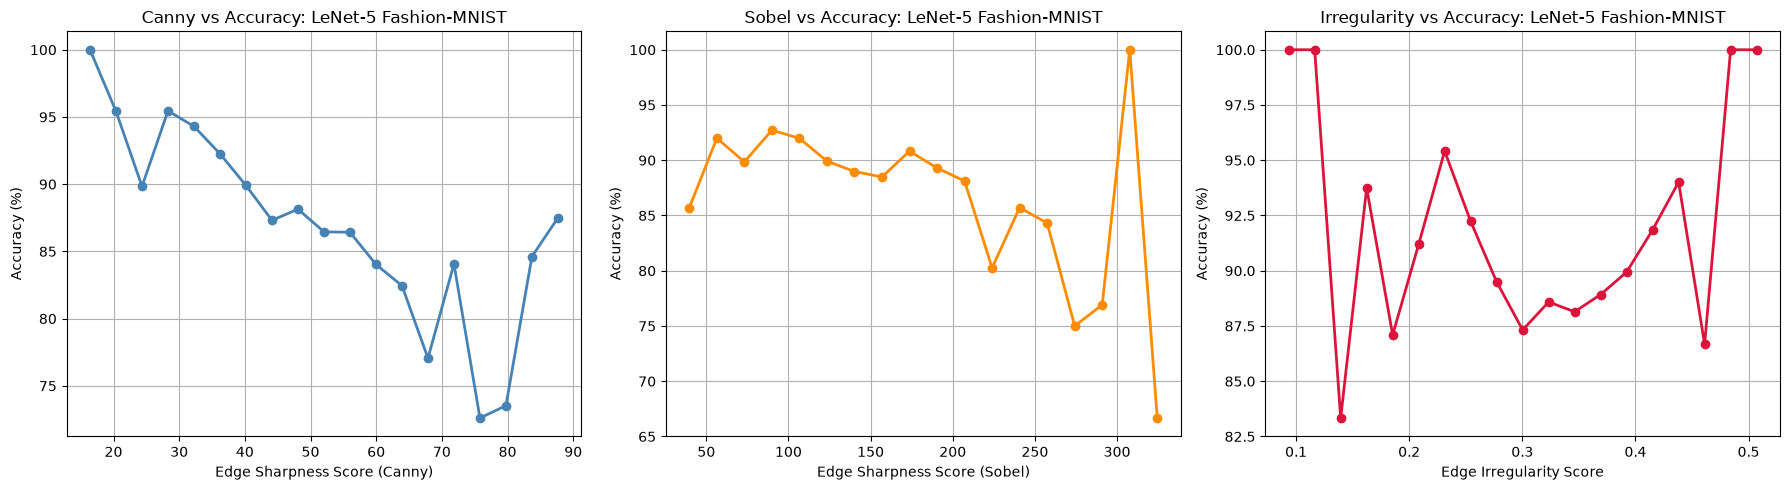

Canny         avg correct: 42.1786 | avg incorrect: 47.4254
Sobel         avg correct: 148.3123 | avg incorrect: 153.6844
Irregularity  avg correct: 0.3184 | avg incorrect: 0.3204

LeNet-5 Dementia


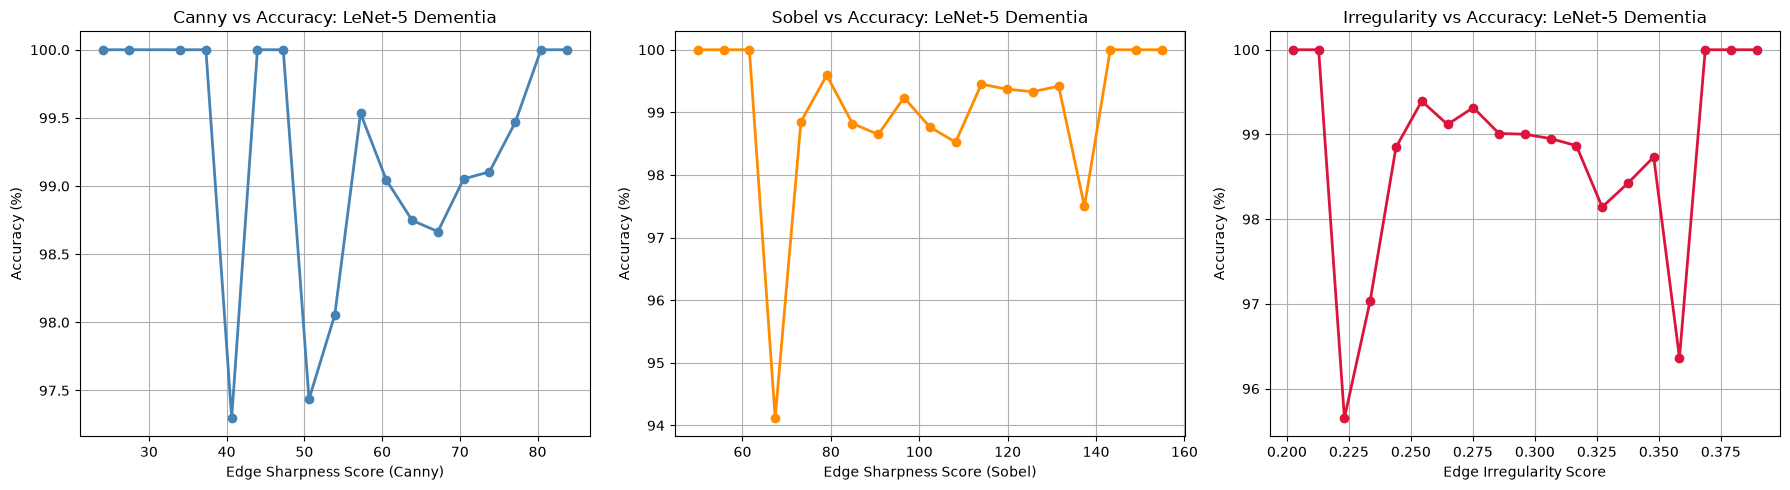

Canny         avg correct: 67.1794 | avg incorrect: 66.2624
Sobel         avg correct: 103.2204 | avg incorrect: 101.9320
Irregularity  avg correct: 0.2900 | avg incorrect: 0.2935

MLP Dementia


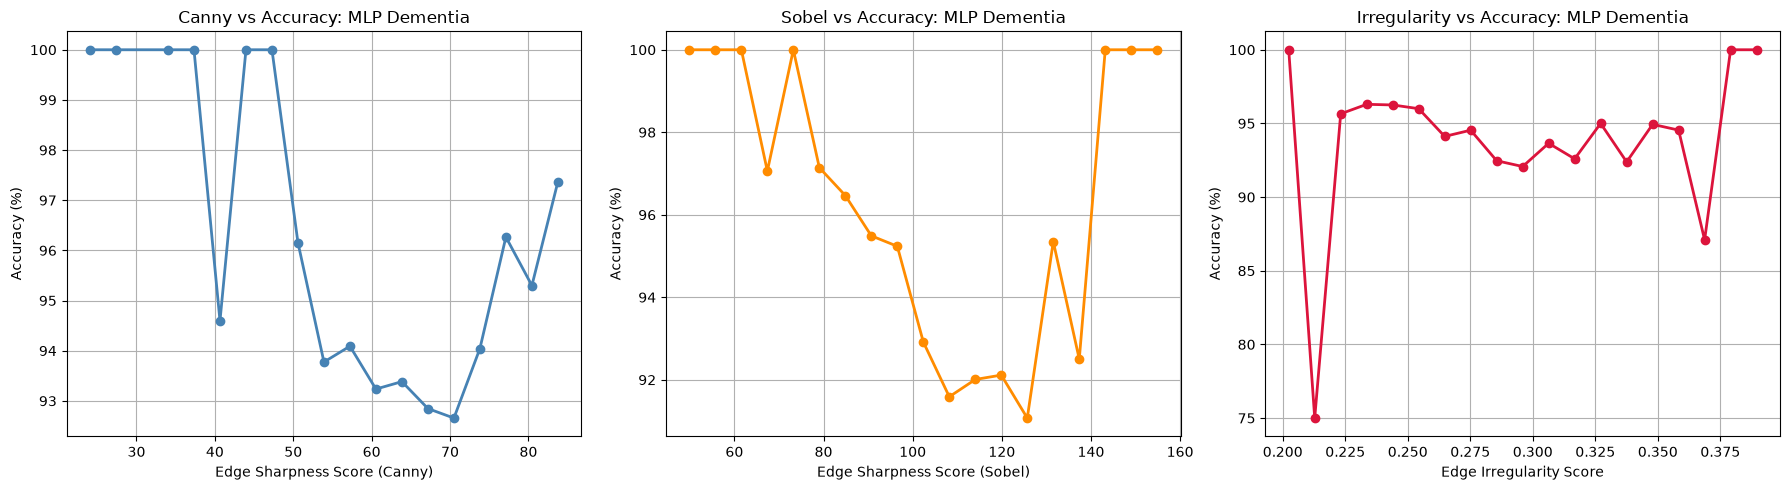

Canny         avg correct: 67.1702 | avg incorrect: 67.1653
Sobel         avg correct: 103.0092 | avg incorrect: 106.0846
Irregularity  avg correct: 0.2899 | avg incorrect: 0.2921

DementiaCNN


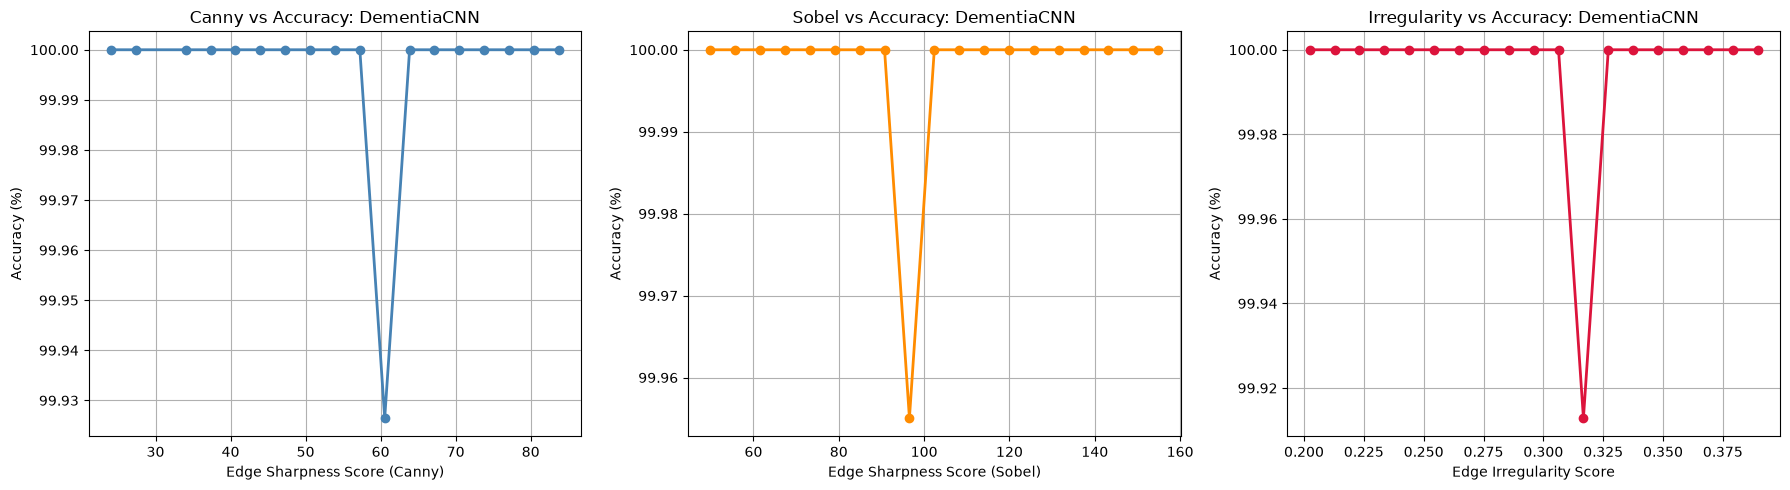

Canny         avg correct: 67.1704 | avg incorrect: 60.2637
Sobel         avg correct: 103.2073 | avg incorrect: 98.3242
Irregularity  avg correct: 0.2901 | avg incorrect: 0.3215


In [22]:
mri_edge_scores = compute_edge_scores(test_loader, normalized=False)
fashion_edge_scores = compute_edge_scores(fashion_test_loader, normalized=True)

edge_runs = [
    ("LeNet-5 Fashion-MNIST", fashion_edge_scores),
    ("LeNet-5 Dementia", mri_edge_scores),
    ("MLP Dementia", mri_edge_scores),
    ("DementiaCNN", mri_edge_scores),
]

for name, scores in edge_runs:
    labels, preds = predictions[name]
    print(f"\n{name}")
    plot_edge_vs_accuracy(scores, preds == labels, name)

## 10. Summary and saved models

In [23]:
summary = pd.DataFrame(results)

# Gap between weighted and macro F1 shows how much class imbalance is hiding
summary["Weighted - Macro F1"] = (summary["Weighted F1"] - summary["Macro F1"]).round(4)
summary

,Model,Test accuracy (%),Macro F1,Weighted F1,Weighted - Macro F1
0,LeNet-5 Dementia,98.96,0.9880,0.9897,0.0017
1,MLP Dementia,93.57,0.8391,0.9328,0.0937
2,DementiaCNN,99.99,0.9998,0.9999,0.0001
3,LeNet-5 Fashion-MNIST,89.45,0.8944,0.8944,0.0000
4,MLP Fashion-MNIST,86.91,0.8693,0.8693,0.0000


In [24]:
trained_models = {
    "lenet5_dementia.pth": lenet_dementia,
    "mlp_dementia.pth":    mlp_dementia,
    "dementia_cnn.pth":    dementia_cnn,
    "lenet5_fashion.pth":  lenet_fashion,
    "mlp_fashion.pth":     mlp_fashion,
}
for filename, model in trained_models.items():
    torch.save(model.state_dict(), MODEL_DIR / filename)
    print(f"Saved -> {MODEL_DIR / filename}")

Saved -> models\lenet5_dementia.pth
Saved -> models\mlp_dementia.pth
Saved -> models\dementia_cnn.pth
Saved -> models\lenet5_fashion.pth
Saved -> models\mlp_fashion.pth
